# OneLand vs TwoLand comparison

Purpose: locate which KPI diverges **beyond** Notebook 1's noise floor.

**Run all cells** — downloads and summarizes both submissions automatically. Noise floor is computed from A.

In [3]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "experiments"))

import submission_nb as snb

ID_A = "56251213"  # OneLand
ID_B = "56300972"  # TwoLand
US_NAME = "Milos Vlainic"  # Kaggle team name (matches info.TeamNames)
REFRESH = False  # True → re-summarize even if JSON exists
NOISE_FLOOR = None  # leave None to compute from A
DAYS = list(range(snb.SEASON_DAYS))

In [4]:
sum_a = snb.ensure_summary(ID_A, US_NAME, ROOT, refresh=REFRESH, verbose=True)
sum_b = snb.ensure_summary(ID_B, US_NAME, ROOT, refresh=REFRESH, verbose=True)
games_a = sum_a.get("games") or []
games_b = sum_b.get("games") or []

if NOISE_FLOOR is None:
    NOISE_FLOOR = snb.noise_floor_from_games(games_a)

print(f"A={ID_A} n={len(games_a)}  B={ID_B} n={len(games_b)}")
print(f"A win_rate={sum_a.get('aggregate', {}).get('win_rate', 0):.3f}")
print(f"B win_rate={sum_b.get('aggregate', {}).get('win_rate', 0):.3f}")
print(f"Noise floor score_std={NOISE_FLOOR.get('score_std', float('nan')):.0f}")

Using cached summary /media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/56251213/56251213.json
Summarizing 56300972 (us_name='Milos Vlainic')...
Analyzing 1/34 episode-109996990-replay.json
Analyzing 2/34 episode-109999283-replay.json
Analyzing 3/34 episode-110000356-replay.json
Analyzing 4/34 episode-110001415-replay.json
Analyzing 5/34 episode-110002482-replay.json
Analyzing 6/34 episode-110003655-replay.json
Analyzing 7/34 episode-110004697-replay.json
Analyzing 8/34 episode-110005771-replay.json
Analyzing 9/34 episode-110006885-replay.json
Analyzing 10/34 episode-110007977-replay.json
Analyzing 11/34 episode-110009071-replay.json
Analyzing 12/34 episode-110010173-replay.json
Analyzing 13/34 episode-110011253-replay.json
Analyzing 14/34 episode-110012361-replay.json
Analyzing 15/34 episode-110013432-replay.json
Analyzing 16/34 episode-110014560-replay.json
Analyzing 17/34 episode-110015640-replay.json
Analyzing 18/34 episode-110016704-replay.json
Analyzing 19/34 episode-110

## 1. Score distributions — half-violins by win/loss


A n=50  B n=34
paired_seeds=1  unpaired_A=49  unpaired_B=33
mean_A=71887  mean_B=64163  delta(B-A)=-7724  noise_std=17542
                    count     mean      std
outcome submission                         
loss    A              27  64558.0  15939.0
        B              18  50072.0  16888.0
win     A              23  80490.0  15550.0
        B              16  80015.0  15507.0


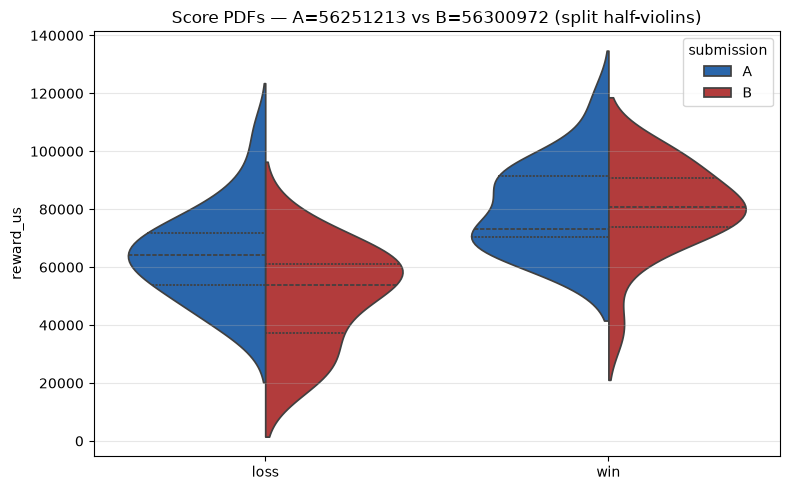

In [5]:
rows = []
for label, games in [("A", games_a), ("B", games_b)]:
    for g in games:
        r = snb.episode_row(g)
        if r["reward_us"] is None:
            continue
        rows.append({
            "submission": label,
            "reward": float(r["reward_us"]),
            "outcome": "win" if r["win"] else "loss",
        })
df_scores = pd.DataFrame(rows)

paired, unpaired_a, unpaired_b = snb.paired_by_seed(games_a, games_b)
mean_a = df_scores.loc[df_scores["submission"] == "A", "reward"].mean()
mean_b = df_scores.loc[df_scores["submission"] == "B", "reward"].mean()
score_std = NOISE_FLOOR.get("score_std", 0) or 1.0

print(f"A n={ (df_scores.submission=='A').sum() }  B n={ (df_scores.submission=='B').sum() }")
print(f"paired_seeds={len(paired)}  unpaired_A={len(unpaired_a)}  unpaired_B={len(unpaired_b)}")
print(f"mean_A={mean_a:.0f}  mean_B={mean_b:.0f}  delta(B-A)={mean_b-mean_a:.0f}  noise_std={score_std:.0f}")
print(df_scores.groupby(["outcome", "submission"])["reward"].agg(["count", "mean", "std"]).round(0))

import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=df_scores,
    x="outcome",
    y="reward",
    hue="submission",
    order=["loss", "win"],
    hue_order=["A", "B"],
    split=True,
    inner="quartile",
    density_norm="width",
    palette={"A": "#1565c0", "B": "#c62828"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("reward_us")
ax.set_title(f"Score PDFs — A={ID_A} vs B={ID_B} (split half-violins)")
ax.legend(title="submission")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Ranked KPI-delta table (effect size vs A noise floor)

In [6]:
def scalar_series(games, key):
    return [float(snb.episode_row(g)[key]) for g in games]

kpi_defs = [
    ("reward_us", lambda g: snb.reward_us(g)),
    ("move_overhead", lambda g: snb.episode_row(g)["move_overhead"]),
    ("noop_ops", lambda g: snb.episode_row(g)["noop_ops"]),
    ("ripe_mean_latency", lambda g: snb.episode_row(g)["ripe_mean_latency"]),
    ("unexplained_delta", lambda g: snb.episode_row(g)["unexplained_delta"]),
    ("tile_day_utilization", lambda g: snb.episode_row(g)["tile_day_utilization"]),
    ("idle_empty", lambda g: snb.episode_row(g)["idle_empty"]),
    ("idle_weed", lambda g: snb.episode_row(g)["idle_weed"]),
    ("total_hire_spend", lambda g: snb.episode_row(g)["total_hire_spend"]),
    ("days_below_floor", lambda g: snb.episode_row(g)["days_below_floor"]),
    ("melon_fill_rate", lambda g: snb.fill_rate_for(g, "MELON")),
    ("wool_fill_rate", lambda g: snb.fill_rate_for(g, "WOOL")),
    ("melon_realized_quote", lambda g: snb.realized_quote_for(g, "MELON")),
    ("wool_realized_quote", lambda g: snb.realized_quote_for(g, "WOOL")),
]

rows = []
for name, fn in kpi_defs:
    va = [float(fn(g)) for g in games_a if fn(g) is not None]
    vb = [float(fn(g)) for g in games_b if fn(g) is not None]
    if not va or not vb:
        continue
    ma, mb = np.mean(va), np.mean(vb)
    d = snb.effect_size(va, vb)
    noise = NOISE_FLOOR.get(name, NOISE_FLOOR.get("score_std", np.std(va)))
    rows.append({
        "kpi": name,
        "mean_A": ma,
        "mean_B": mb,
        "delta_B_minus_A": mb - ma,
        "effect_size": d,
        "noise_std_A": noise,
        "beyond_noise": abs(mb - ma) > (noise or 0),
    })

df_rank = pd.DataFrame(rows).sort_values("effect_size", key=lambda s: s.abs(), ascending=False)
display(df_rank)

,kpi,mean_A,mean_B,delta_B_minus_A,effect_size,noise_std_A,beyond_noise
8,total_hire_spend,1820.620000,16334.264706,14513.644706,-7.563010,201.357423,True
6,idle_empty,7302.680000,10143.852941,2841.172941,-2.792399,17541.900060,False
1,move_overhead,0.728328,0.761478,0.033150,-1.088992,0.026846,True
4,unexplained_delta,2697.960000,4481.029412,1783.069412,-0.645227,2119.696859,False
12,melon_realized_quote,0.986576,0.973091,-0.013485,0.496138,17541.900060,False
3,ripe_mean_latency,44.551739,46.786033,2.234293,-0.463925,4.861939,False
5,tile_day_utilization,0.759403,0.745673,-0.013730,0.409158,0.029051,False
0,reward_us,71886.600000,64162.794118,-7723.805882,0.396428,17541.900060,False
7,idle_weed,111.060000,325.470588,214.410588,-0.384059,17541.900060,False
2,noop_ops,9.000000,10.970588,1.970588,-0.356677,4.342481,False


## 3. Land-lifecycle alignment (B reindexed to days since NE buy vs A calendar baseline)

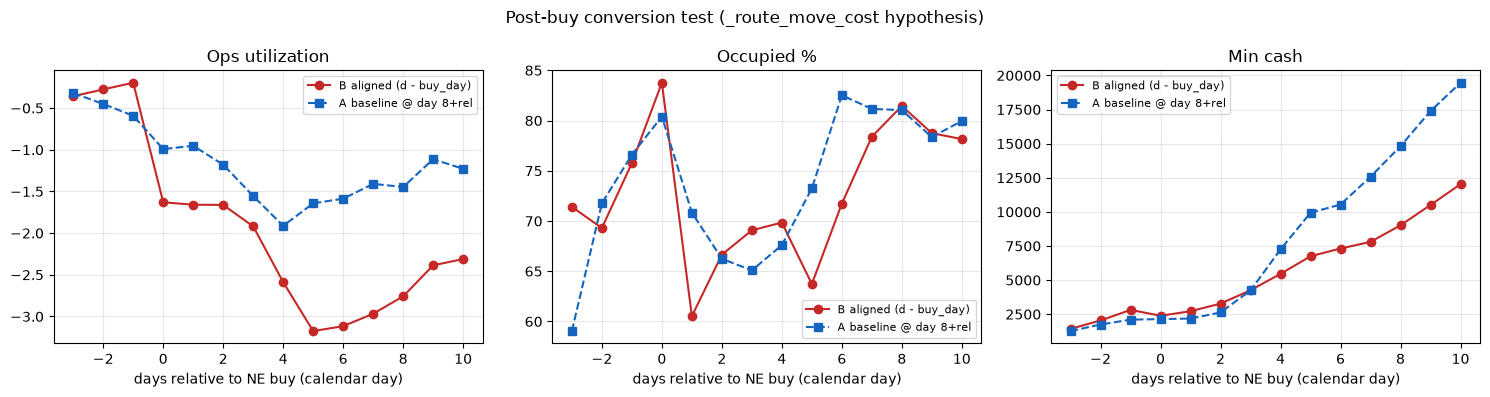

In [7]:
REL_RANGE = list(range(-3, 11))

def mean_aligned(games_b, series_fn, rel_range=REL_RANGE):
    buckets = {r: [] for r in rel_range}
    for g in games_b:
        buy = snb.ne_buy_day(g)
        if buy is None:
            continue
        aligned = snb.aligned_series(g, series_fn, buy, pre=max(-r for r in rel_range), post=max(rel_range))
        for r, v in aligned.items():
            if r in buckets:
                buckets[r].append(v)
    return {r: (np.mean(buckets[r]) if buckets[r] else np.nan) for r in rel_range}

baseline_ops = snb.day_band(games_a, snb.ops_util_series)[0]
baseline_occ = snb.day_band(games_a, snb.occupied_pct_series)[0]
baseline_cash = snb.day_band(games_a, snb.min_cash_series)[0]

aligned_ops = mean_aligned(games_b, snb.ops_util_series)
aligned_occ = mean_aligned(games_b, snb.occupied_pct_series)
aligned_cash = mean_aligned(games_b, snb.min_cash_series)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
specs = [
    ("Ops utilization", aligned_ops, lambda d: baseline_ops[d] if 0 <= d < len(baseline_ops) else np.nan, "calendar day"),
    ("Occupied %", aligned_occ, lambda d: baseline_occ[d] if 0 <= d < len(baseline_occ) else np.nan, "calendar day"),
    ("Min cash", aligned_cash, lambda d: baseline_cash[d] if 0 <= d < len(baseline_cash) else np.nan, "calendar day"),
]
for ax, (title, b_series, a_fn, xlabel) in zip(axes, specs):
    rels = list(b_series.keys())
    ax.plot(rels, [b_series[r] for r in rels], "o-", color="#c62828", label="B aligned (d - buy_day)")
    # overlay A at matched calendar days = buy_day + rel (use mean buy day)
    buy_days = [snb.ne_buy_day(g) for g in games_b if snb.ne_buy_day(g) is not None]
    if buy_days:
        mean_buy = int(np.mean(buy_days))
        a_vals = [a_fn(mean_buy + r) for r in rels]
        ax.plot(rels, a_vals, "s--", color="#1565c0", label=f"A baseline @ day {mean_buy}+rel")
    ax.set_title(title)
    ax.set_xlabel(f"days relative to NE buy ({xlabel})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle("Post-buy conversion test (_route_move_cost hypothesis)")
plt.tight_layout()
plt.show()

## 4. Move-overhead and idle tile turns

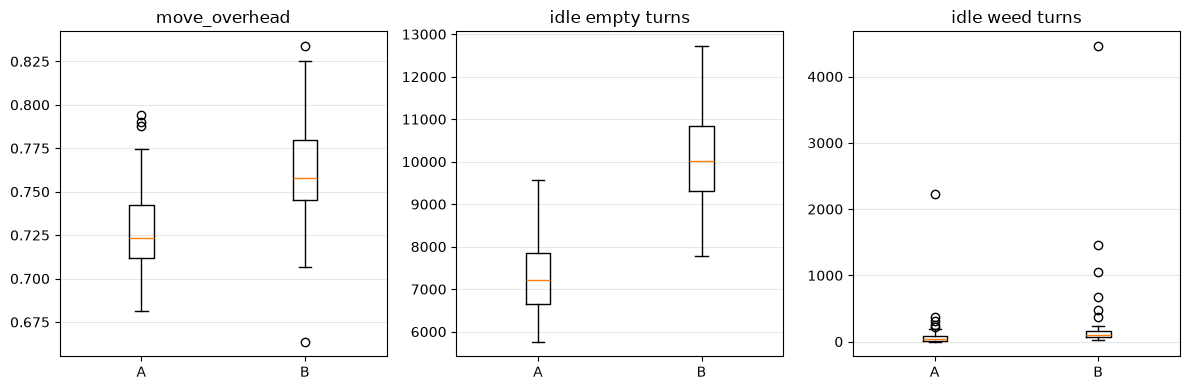

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, key, title in zip(
    axes,
    ["move_overhead", "idle_empty", "idle_weed"],
    ["move_overhead", "idle empty turns", "idle weed turns"],
):
    va = [snb.episode_row(g)[key] for g in games_a]
    vb = [snb.episode_row(g)[key] for g in games_b]
    ax.boxplot([va, vb], tick_labels=["A", "B"])
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Revenue per tile-day by crop

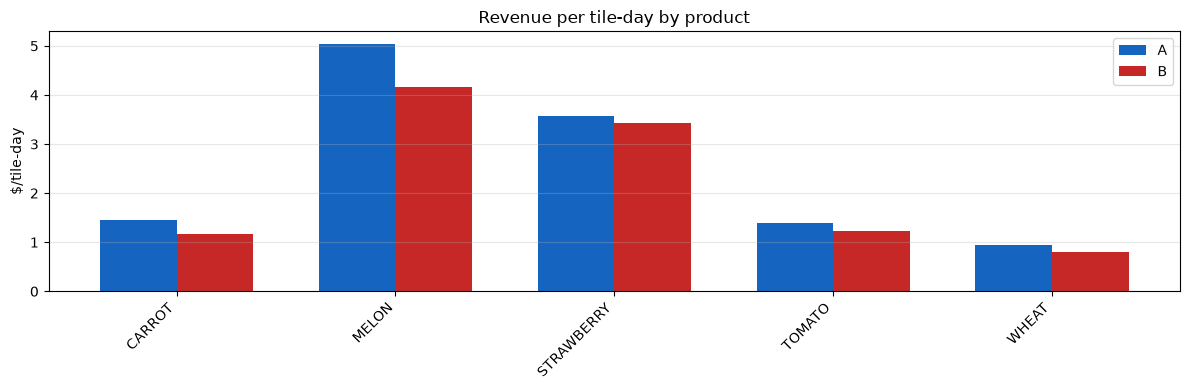

In [9]:
def mean_rev_per_tile(games):
    acc: dict[str, list[float]] = {}
    for g in games:
        _, _, plan_k = snb.us_kpi(g)
        for prod, val in (plan_k.get("revenue_per_tile_day_by_crop") or {}).items():
            acc.setdefault(prod, []).append(float(val))
    return {p: np.mean(v) for p, v in acc.items()}

rev_a = mean_rev_per_tile(games_a)
rev_b = mean_rev_per_tile(games_b)
prods = sorted(set(rev_a) | set(rev_b))

x = np.arange(len(prods))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w / 2, [rev_a.get(p, 0) for p in prods], w, label="A", color="#1565c0")
ax.bar(x + w / 2, [rev_b.get(p, 0) for p in prods], w, label="B", color="#c62828")
ax.set_xticks(x)
ax.set_xticklabels(prods, rotation=45, ha="right")
ax.set_ylabel("$/tile-day")
ax.set_title("Revenue per tile-day by product")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Fill-rate / glut — MELON and WOOL

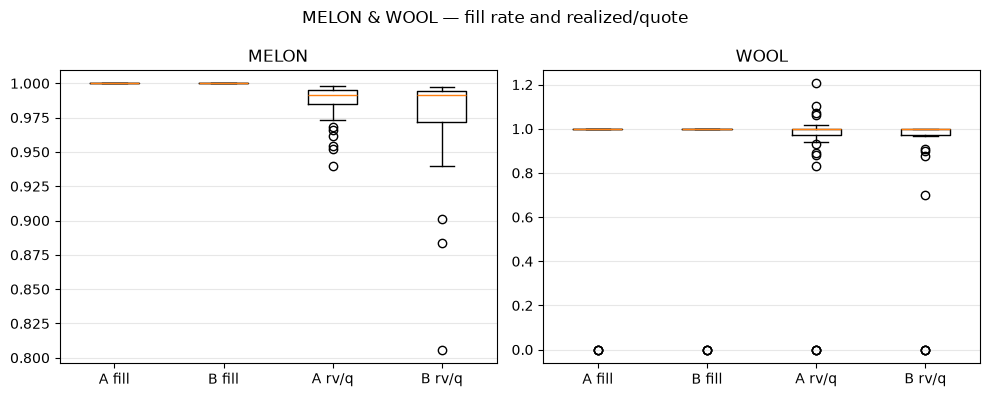

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, prod in zip(axes, ["MELON", "WOOL"]):
    fa = [snb.fill_rate_for(g, prod) for g in games_a]
    fb = [snb.fill_rate_for(g, prod) for g in games_b]
    ra = [snb.realized_quote_for(g, prod) for g in games_a]
    rb = [snb.realized_quote_for(g, prod) for g in games_b]
    ax.boxplot([fa, fb, ra, rb], tick_labels=["A fill", "B fill", "A rv/q", "B rv/q"])
    ax.set_title(prod)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("MELON & WOOL — fill rate and realized/quote")
plt.tight_layout()
plt.show()

## 7. Hire-spend and cash floor around land-buy (±3 days)

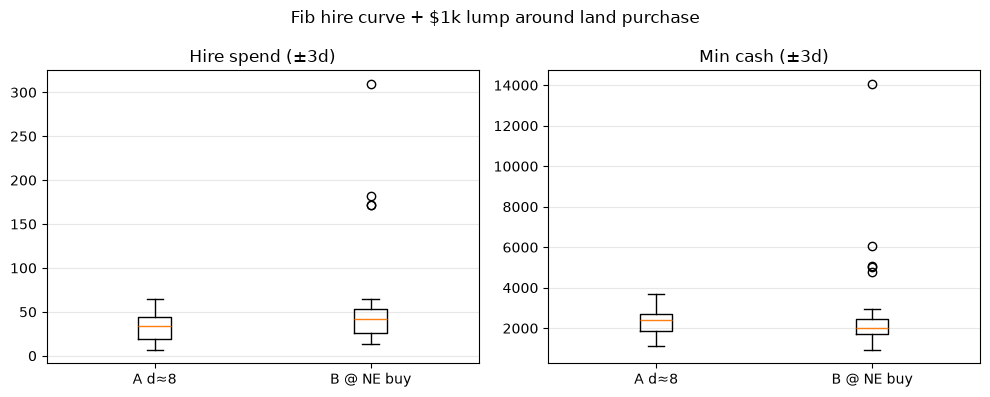

In [11]:
WIN = 3

def window_mean(games, buy_day_fn, series_name):
    """Mean hire_spend or min_cash in [buy-WIN, buy+WIN] for games with a buy."""
    vals = []
    for g in games:
        buy = buy_day_fn(g)
        if buy is None:
            continue
        _, _, plan_k = snb.us_kpi(g)
        if series_name == "hire":
            s = plan_k.get("hire_profile", {}).get("hire_spend_by_day") or []
        else:
            s = plan_k.get("min_cash_by_day") or []
        window = [s[d] for d in range(max(0, buy - WIN), min(len(s), buy + WIN + 1))]
        if window:
            vals.append(np.mean(window))
    return vals

# B: around NE buy; A: same calendar window using mean B buy day
buy_days_b = [snb.ne_buy_day(g) for g in games_b if snb.ne_buy_day(g) is not None]
mean_buy_b = int(np.mean(buy_days_b)) if buy_days_b else 8

def calendar_window(games, center_day, series_name):
    vals = []
    for g in games:
        _, _, plan_k = snb.us_kpi(g)
        if series_name == "hire":
            s = plan_k.get("hire_profile", {}).get("hire_spend_by_day") or []
        else:
            s = plan_k.get("min_cash_by_day") or []
        window = [s[d] for d in range(max(0, center_day - WIN), min(len(s), center_day + WIN + 1))]
        if window:
            vals.append(np.mean(window))
    return vals

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, series_name, title in zip(axes, ["hire", "cash"], ["Hire spend (±3d)", "Min cash (±3d)"]):
    b_hire = window_mean(games_b, snb.ne_buy_day, series_name)
    a_hire = calendar_window(games_a, mean_buy_b, series_name)
    ax.boxplot([a_hire, b_hire], tick_labels=[f"A d≈{mean_buy_b}", "B @ NE buy"])
    ax.set_title(title)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Fib hire curve + $1k lump around land purchase")
plt.tight_layout()
plt.show()